# Analyse et Préparation des Données

## Objectif : 
    Analyser et préparer les données des assurés pour garantir qu'elles sont propres, cohérentes et prêtes pour l'entraînement du modèle.

## Tâche 1 : Chargement des données
    - Importer les données à l'aide de la bibliothèque Pandas.
    - Vérifier le type et la structure des colonnes.


In [ ]:
import pandas as pd 
df = pd.read_csv("assurance-maladie.csv")

In [4]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [6]:
df.shape

(1338, 7)

## Tâche 2 : Analyse exploratoire des données (EDA)
- Comprendre la structure générale du jeu de données (types de données, dimensions, aperçus).

In [7]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [8]:
df.shape

(1338, 7)

In [9]:
df.info

<bound method DataFrame.info of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

In [10]:
df.describe

<bound method NDFrame.describe of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

In [11]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


- Effectuer une analyse descriptive des données (moyennes, médianes, écarts-types pour les variables numériques ; fréquences pour les catégoriques).

In [17]:
num_cols = df.select_dtypes(include='number')

print("Moyennes :\n",   num_cols.mean())

Moyennes :
 age            39.207025
bmi            30.663397
children        1.094918
charges     13270.422265
dtype: float64


In [18]:
print("Médianes :\n",   num_cols.median())

Médianes :
 age           39.000
bmi           30.400
children       1.000
charges     9382.033
dtype: float64


In [21]:
print("Ecarts-types :\n",  num_cols.std())

Ecarts-types :
 age            14.049960
bmi             6.098187
children        1.205493
charges     12110.011237
dtype: float64


In [15]:
print("le coefficient d’asymétrie skewness")
num_cols.skew()


le coefficient d’asymétrie skewness


age         0.055673
bmi         0.284047
children    0.938380
charges     1.515880
dtype: float64

### fréquences pour les catégoriques

In [28]:
cat_cols = df.select_dtypes(include='object')

for col in cat_cols.columns:
    print("\n", col)
    print(df[col].value_counts())


 sex
sex
male      676
female    662
Name: count, dtype: int64

 smoker
smoker
no     1064
yes     274
Name: count, dtype: int64

 region
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


C:\Users\xFawzer\AppData\Local\Temp\ipykernel_30564\3000948779.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object')


- Identifier les valeurs manquantes et les doublons.

In [29]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

- Pourcentage des valeurs manquantes (juste pour moi)

In [33]:
missing_pourcentage = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pourcentage

age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64

- Visualiser les manquants avec une heatmap : (juste pour moi)

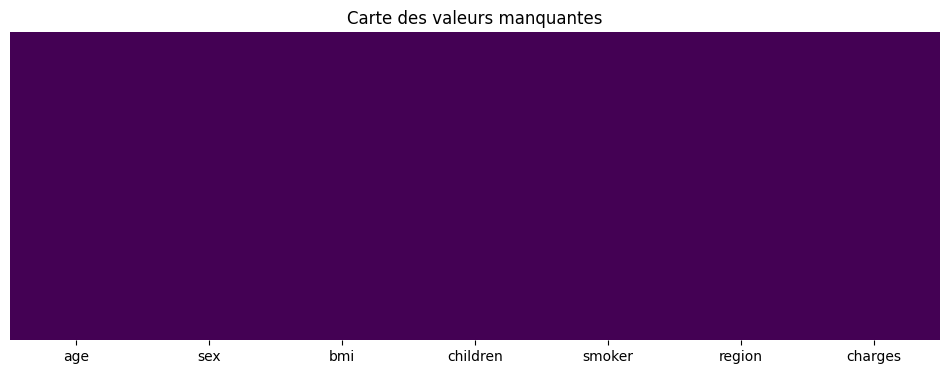

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Carte des valeurs manquantes")
plt.show()

- les doublons

In [46]:
print("Nomdes des doublons", df.duplicated().sum())

print("\n\nla ligne dupliquée ", df[df.duplicated()])

print("\nles deux lignes\n", df[df.duplicated(keep=False)])

Nomdes des doublons 1


la ligne dupliquée       age   sex    bmi  children smoker     region    charges
581   19  male  30.59         0     no  northwest  1639.5631

les deux lignes
      age   sex    bmi  children smoker     region    charges
195   19  male  30.59         0     no  northwest  1639.5631
581   19  male  30.59         0     no  northwest  1639.5631


- Analyser la distribution des variables numériques (ex. : histogrammes avec Matplotlib/Seaborn).

- Étudier les relations entre variables à l'aide de matrices de corrélation et de visualisations (ex. : pairplots ou heatmaps).